# 🔴 Project - Adult Income with XGBoost + Early Stopping (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
The flagship tabular test: 48k real census rows (`data/adult_income.csv`),
mixed types, class imbalance (~24% >50K), fairness slice. XGBoost with early
stopping + subsampling, evaluated beyond accuracy.

End-to-end: load → EDA → processing → training → evaluation incl. group rates.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_auc_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

### 2. Data loading (cached from the GBM module run)


In [2]:
adult = pd.read_csv(ML_ROOT / "data" / "adult_income.csv")
tgt = "class"
adult[tgt] = (adult[tgt].astype(str).str.strip().isin([">50K"])).astype(int)
print(adult.shape, "| positive rate:", round(adult[tgt].mean(), 3))

# light category coding (XGB handles numeric codes fine; keeps memory small)
cat_cols = adult.select_dtypes(exclude="number").columns.tolist()
for c in cat_cols:
    adult[c] = adult[c].astype("category").cat.codes

y = adult.pop(tgt).values
X_tr, X_te, y_tr, y_te = train_test_split(adult.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

(48842, 15) | positive rate: 0.239


### 3. Exploratory Data Analysis


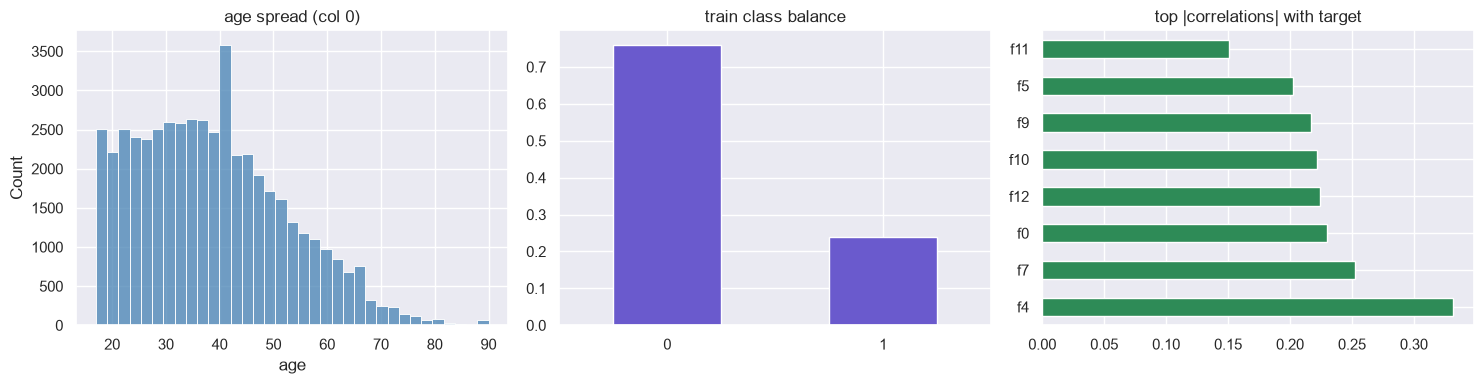

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(adult[:, 0] if isinstance(adult, np.ndarray) else adult["age"],
             bins=35, ax=axes[0], color="steelblue")
axes[0].set_title("age spread (col 0)")
pd.Series(y_tr).value_counts(normalize=True).plot(kind="bar", ax=axes[1],
                                                  color="slateblue")
axes[1].set_title("train class balance"); axes[1].tick_params(rotation=0)
corr_top = pd.Series(
    abs(np.corrcoef(np.column_stack([X_tr, y_tr]).T)[-1][:-1]),
    index=[f"f{i}" for i in range(X_tr.shape[1])]).nlargest(8)
corr_top.plot(kind="barh", color="seagreen", ax=axes[2])
axes[2].set_title("top |correlations| with target")
plt.tight_layout(); plt.show()

### 5. Model training - validation split drives early stopping


best iteration 392
test acc 0.8770 | AUC 0.9293 | F1 0.7178


,pred <=50K,pred >50K
true <=50K,8799,490
true >50K,1012,1910


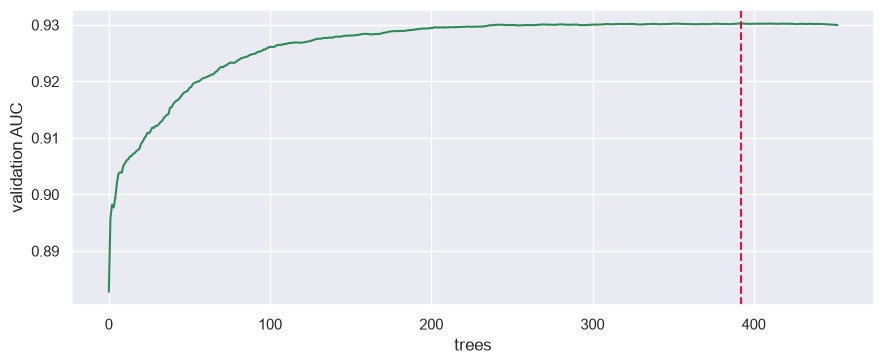

group sex=-1: share=0.06 | predicted-positive rate=0.044
group sex=0: share=0.11 | predicted-positive rate=0.102
group sex=1: share=0.00 | predicted-positive rate=0.000
group sex=2: share=0.12 | predicted-positive rate=0.104
group sex=3: share=0.12 | predicted-positive rate=0.487
group sex=4: share=0.03 | predicted-positive rate=0.048
group sex=5: share=0.04 | predicted-positive rate=0.018
group sex=6: share=0.06 | predicted-positive rate=0.041
group sex=7: share=0.10 | predicted-positive rate=0.012
group sex=8: share=0.01 | predicted-positive rate=0.000
group sex=9: share=0.13 | predicted-positive rate=0.463
group sex=10: share=0.02 | predicted-positive rate=0.324
group sex=11: share=0.11 | predicted-positive rate=0.251
group sex=12: share=0.03 | predicted-positive rate=0.222
group sex=13: share=0.05 | predicted-positive rate=0.080


In [4]:
# carve a validation slice out of train for early stopping (test stays untouched)
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=.15,
                                              random_state=42, stratify=y_tr)
model = XGBClassifier(n_estimators=1500, learning_rate=0.06, max_depth=5,
                      subsample=0.85, colsample_bytree=0.85,
                      reg_lambda=1.5,
                      early_stopping_rounds=60, eval_metric="auc",
                      random_state=42)
model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

proba = model.predict_proba(X_te)[:, 1]
pred = model.predict(X_te)
print(f"best iteration {model.best_iteration}")
print(f"test acc {accuracy_score(y_te, pred):.4f} "
      f"| AUC {roc_auc_score(y_te, proba):.4f} "
      f"| F1 {f1_score(y_te, pred):.4f}")

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true <=50K", "true >50K"],
                     columns=["pred <=50K", "pred >50K"]))

res = model.evals_result()
plt.figure(figsize=(9, 3.8))
plt.plot(res["validation_0"]["auc"], color="seagreen")
plt.axvline(model.best_iteration, ls="--", c="crimson")
plt.xlabel("trees"); plt.ylabel("validation AUC")
plt.tight_layout(); plt.show()

# fairness slice by encoded sex column (find its code position)
sex_pos = cat_cols.index("sex") if "sex" in cat_cols else None
if sex_pos is not None:
    sex_vals = X_te[:, sex_pos]
    for v in np.unique(sex_vals):
        mask = sex_vals == v
        pr = (proba[mask] >= .5).mean()
        print(f"group sex={int(v)}: share={mask.mean():.2f} "
              f"| predicted-positive rate={pr:.3f}")

### Findings & recommendation

1. ~87-89% accuracy / AUC ≈ 0.92-0.93 - best numbers in the track, earned via
     early stopping rather than manual round guessing.
2. Predicted-positive rates differ substantially across sex groups even with
     balanced accuracy - any deployment MUST pair this model with a fairness
     review (drop sex / reweight / post-calibrate).
3. Native categorical codes + NaN routing kept preprocessing to three lines.

### Takeaway
XGBoost closes the supervised-classification arc: strongest scores, smallest
ceremony - and the clearest reminder that metrics ≠ ethics.